# Calibracion de Probabilidades para Deteccion de Impago

**Objetivo:** evaluar si el modelo CatBoost entrenado en el notebook 07 necesita
calibracion de probabilidades y, en caso afirmativo, comparar cuatro metodos
de calibracion post-hoc: **Platt Scaling**, **Isotonic Regression**, **Beta Calibration**
y **Venn-Abers**.

## Por que importa la calibracion en riesgo de credito?

En banca, las probabilidades de default (PD) no son solo un score de ranking — se usan
directamente para:
- **Perdidas esperadas**: $EL = PD \times LGD \times EAD$
- **Provisiones** bajo IFRS 9
- **Pricing** de creditos (cuanto mayor la PD, mayor el tipo de interes)
- **Capital regulatorio** bajo Basilea III/IV

Un modelo con buen AUC (buena discriminacion) pero mala calibracion produce PDs que
**no reflejan la frecuencia real de default**. Esto lleva a subestimar o sobreestimar
riesgo — ambos costosos.

**Metricas de referencia del notebook 07 (CatBoost sobre test):**

| Metrica | CatBoost |
|---|---|
| AUC-ROC | 0.7079 |
| Recall (Default) | 0.63 |
| F1 (Default) | 0.43 |

**Librerias utilizadas:**
- `scikit-learn` — Platt scaling e isotonic regression via `CalibratedClassifierCV`
- `betacal` — Beta calibration (Kull et al., 2017)
- `venn-abers` — Venn-Abers predictor (Vovk & Petej, 2014)

## PASO 1: Carga de datos preprocesados

In [ ]:
import pickle
import numpy as np
import pandas as pd

# Cargar datos preprocesados y filtrados desde pkl
with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_filtered = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_filtered = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)

y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

print(f"Train: {X_train_filtered.shape}")
print(f"Test:  {X_test_filtered.shape}")

n_negative = np.sum(y_train_flat == 0)
n_positive = np.sum(y_train_flat == 1)
print(f"\nClase mayoritaria (Fully Paid): {n_negative}")
print(f"Clase minoritaria (Default):    {n_positive}")
print(f"Ratio:                          {n_negative/n_positive:.2f}")

Train: (80000, 163)
Test:  (20000, 163)

Clase mayoritaria (Fully Paid): 63764
Clase minoritaria (Default):    16236
Ratio:                          3.93


## PASO 2: Division train / validacion / calibracion

Para calibrar las probabilidades necesitamos **tres conjuntos** disjuntos:
1. **Train** (60%): entrenar el modelo CatBoost
2. **Validacion** (20%): early stopping durante el entrenamiento
3. **Calibracion** (20%): ajustar los metodos de calibracion post-hoc

El conjunto de **test** (ya separado) se usa para evaluar la calibracion.

```
Train original (80,000)
├── Train (48,000)      -> entrenar CatBoost
├── Validacion (16,000) -> early stopping
└── Calibracion (16,000) -> ajustar calibradores

Test (20,000)           -> evaluar calibracion
```

> **Importante:** el conjunto de calibracion debe ser **independiente** del de
> entrenamiento. Si calibramos sobre los mismos datos usados para entrenar,
> los calibradores se ajustan a las probabilidades sobreajustadas del modelo
> y la calibracion no generaliza a datos nuevos.

In [ ]:
from sklearn.model_selection import train_test_split

# Paso 1: separar calibracion (20%) del resto (80%)
X_train_rest, X_cal, y_train_rest, y_cal = train_test_split(
    X_train_filtered, y_train_flat, test_size=0.2, random_state=42, stratify=y_train_flat
)

# Paso 2: separar train (75% del resto = 60% original) y validacion (25% del resto = 20% original)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_rest, y_train_rest, test_size=0.25, random_state=42, stratify=y_train_rest
)

print(f"Train:       {X_train_sub.shape}  ({len(X_train_sub)/len(X_train_filtered)*100:.0f}%)")
print(f"Validacion:  {X_val.shape}  ({len(X_val)/len(X_train_filtered)*100:.0f}%)")
print(f"Calibracion: {X_cal.shape}  ({len(X_cal)/len(X_train_filtered)*100:.0f}%)")
print(f"Test:        {X_test_filtered.shape}")

Train:       (48000, 163)  (60%)
Validacion:  (16000, 163)  (20%)
Calibracion: (16000, 163)  (20%)
Test:        (20000, 163)


## PASO 3: Entrenamiento de CatBoost

Usamos los mismos hiperparametros del notebook 07. La unica diferencia es que
entrenamos sobre el 60% de los datos (en lugar del 80%) para reservar el conjunto
de calibracion.

In [ ]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    min_data_in_leaf=20,
    subsample=0.8,
    colsample_bylevel=0.8,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=50,
    eval_metric='AUC'
)

catboost_model.fit(
    X_train_sub, y_train_sub,
    eval_set=(X_val, y_val),
    verbose=200
)

0:	test: 0.6565398	best: 0.6565398 (0)	total: 21.8ms	remaining: 1m 49s
200:	test: 0.7067068	best: 0.7067068 (200)	total: 2.06s	remaining: 49.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7077544343
bestIteration = 240

Shrink model to first 241 iterations.


CatBoostClassifier(auto_class_weights='Balanced', colsample_bylevel=0.8, depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=5000, l2_leaf_reg=3, learning_rate=0.05, min_data_in_leaf=20, random_seed=42, subsample=0.8, verbose=200)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, log_loss

y_pred = catboost_model.predict(X_test_filtered)
y_prob = catboost_model.predict_proba(X_test_filtered)[:, 1]

print("Evaluacion de CatBoost sobre Test:")
print(classification_report(y_test_flat, y_pred, target_names=["Fully Paid", "Default"]))
print(f"AUC-ROC:     {roc_auc_score(y_test_flat, y_prob):.4f}")
print(f"Brier Score: {brier_score_loss(y_test_flat, y_prob):.4f}")
print(f"Log-Loss:    {log_loss(y_test_flat, y_prob):.4f}")

Evaluacion de CatBoost sobre Test:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.67      0.76     16003
     Default       0.32      0.63      0.43      3997

    accuracy                           0.66     20000
   macro avg       0.60      0.65      0.59     20000
weighted avg       0.77      0.66      0.69     20000

AUC-ROC:     0.7041
Brier Score: 0.2138
Log-Loss:    0.6156


## PASO 4: Necesita CatBoost calibracion?

Antes de aplicar calibradores a ciegas, debemos **diagnosticar** si el modelo
realmente necesita calibracion. Como dice Manokhin (2025): *"nunca optimices solo
para Brier score — optimiza discriminacion (AUC) y luego arregla la calibracion
post-hoc si el Z-estadistico esta por encima de 1.96"*.

### Marco teorico: Descomposicion de Brier (Murphy/Spiegelhalter)

El Brier score es el error cuadratico medio de las probabilidades predichas:

$$BS = \frac{1}{N} \sum_{i=1}^{N} (y_i - p_i)^2$$

Pero este numero unico **mezcla dos propiedades** que apuntan en direcciones opuestas.
La descomposicion de Murphy (1973) / Spiegelhalter (1986) las separa:

$$\text{Brier} = \underbrace{\text{Reliability}}_{\text{calibracion}} - \underbrace{\text{Resolution}}_{\text{discriminacion}} + \underbrace{\text{Uncertainty}}_{\text{dato}}$$

| Componente | Que mide | Bueno si... |
|---|---|---|
| **Reliability** (fiabilidad) | Calibracion: cuanto se desvian las probabilidades predichas de las frecuencias observadas en cada bin | **Bajo** (0 = calibracion perfecta) |
| **Resolution** (resolucion) | Discriminacion: cuanto varian las frecuencias observadas entre bins respecto a la tasa base | **Alto** (bins con frecuencias muy distintas = buena separacion) |
| **Uncertainty** (incertidumbre) | Propiedad del dataset: $\bar{y}(1-\bar{y})$ | Constante, no depende del modelo |

### El test de Spiegelhalter (1986)

Test formal de calibracion. Bajo $H_0$ de calibracion perfecta (cuando $p_i$ es la
probabilidad real), el Brier score tiene una expectativa y varianza conocidas:

$$E[BS | H_0] = \frac{1}{N} \sum_{i=1}^{N} p_i(1 - p_i)$$

$$Var[BS | H_0] = \frac{1}{N^2} \sum_{i=1}^{N} (1 - 2p_i)^2 \cdot p_i(1 - p_i)$$

$$Z = \frac{BS - E[BS|H_0]}{\sqrt{Var[BS|H_0]}}$$

- $|Z| < 1.96$: **no rechazamos $H_0$** → las probabilidades estan calibradas
- $|Z| > 1.96$: **rechazamos $H_0$** → las probabilidades **NO** estan calibradas → **necesita calibracion**

### El playbook de diagnostico

| AUC | \|Z\| | Interpretacion | Accion |
|---|---|---|---|
| Alto | < 1.96 | Buena discriminacion Y buena calibracion | **Usar tal cual** |
| Alto | > 1.96 | Buena discriminacion, mala calibracion | **Calibrar post-hoc** |
| Bajo | > 1.96 | Mala discriminacion Y mala calibracion | **Reentrenar** |
| Bajo | < 1.96 | Bien calibrado pero no discrimina | Inutil (predice la tasa base) |

> *Referencia: Manokhin, V. (2025). "Stop Using Brier Score Wrong". Basado en
> la descomposicion de Spiegelhalter (1986) aplicada a 21 clasificadores sobre 30 datasets
> del benchmark TabArena-v0.1 (arXiv:2601.19944).*

### 4.1 Curva de calibracion (inspeccion visual)

La curva de calibracion (reliability diagram) agrupa las predicciones en bins
y compara la probabilidad media predicha con la frecuencia observada de positivos.
Una curva perfectamente calibrada sigue la diagonal.

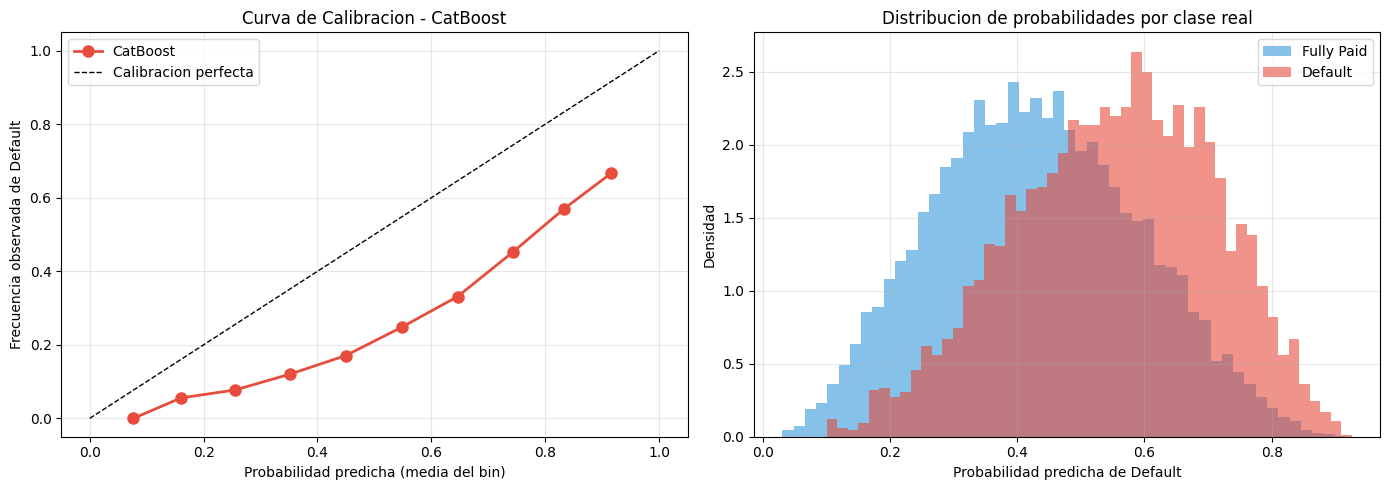

Detalle por bin:
    Bin  Prob predicha   Freq observada   Desviacion
  --------------------------------------------------
      1         0.0769           0.0000      +0.0769
      2         0.1602           0.0555      +0.1047
      3         0.2553           0.0771      +0.1781
      4         0.3523           0.1205      +0.2318
      5         0.4499           0.1709      +0.2790
      6         0.5481           0.2480      +0.3001
      7         0.6462           0.3313      +0.3149
      8         0.7429           0.4519      +0.2910
      9         0.8335           0.5704      +0.2631
     10         0.9158           0.6667      +0.2492


In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de calibracion
prob_true, prob_pred = calibration_curve(y_test_flat, y_prob, n_bins=10, strategy='uniform')

axes[0].plot(prob_pred, prob_true, 'o-', color='#e74c3c', lw=2, markersize=8, label='CatBoost')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Calibracion perfecta')
axes[0].set_xlabel('Probabilidad predicha (media del bin)')
axes[0].set_ylabel('Frecuencia observada de Default')
axes[0].set_title('Curva de Calibracion - CatBoost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de probabilidades predichas
axes[1].hist(y_prob[y_test_flat == 0], bins=50, alpha=0.6, label='Fully Paid', color='#3498db', density=True)
axes[1].hist(y_prob[y_test_flat == 1], bins=50, alpha=0.6, label='Default', color='#e74c3c', density=True)
axes[1].set_xlabel('Probabilidad predicha de Default')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribucion de probabilidades por clase real')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Desviaciones por bin
print("Detalle por bin:")
print(f"  {'Bin':>5} {'Prob predicha':>14} {'Freq observada':>16} {'Desviacion':>12}")
print(f"  {'-'*50}")
for i in range(len(prob_true)):
    dev = prob_pred[i] - prob_true[i]
    print(f"  {i+1:>5} {prob_pred[i]:>14.4f} {prob_true[i]:>16.4f} {dev:>+12.4f}")

### 4.2 Descomposicion de Brier Score (Murphy)

Separamos el Brier score en sus tres componentes para entender **donde** falla
el modelo: en calibracion (reliability) o en discriminacion (resolution).

In [ ]:
def brier_decomposition(y_true, y_prob, n_bins=10):
    """
    Descomposicion de Murphy del Brier score:
    Brier = Reliability - Resolution + Uncertainty

    - Reliability (calibracion): menor es mejor (0 = perfecto)
    - Resolution (discriminacion): mayor es mejor
    - Uncertainty: constante del dataset
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    N = len(y_true)
    o_bar = y_true.mean()  # tasa base de positivos

    reliability = 0.0
    resolution = 0.0
    bin_details = []

    for k in range(n_bins):
        mask = bin_indices == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        p_bar_k = y_prob[mask].mean()    # probabilidad media predicha en bin k
        o_bar_k = y_true[mask].mean()    # frecuencia observada en bin k

        reliability += n_k * (p_bar_k - o_bar_k) ** 2
        resolution += n_k * (o_bar_k - o_bar) ** 2

        bin_details.append({
            'bin': k + 1, 'n': n_k, 'p_pred': p_bar_k,
            'p_obs': o_bar_k, 'gap': abs(p_bar_k - o_bar_k)
        })

    reliability /= N
    resolution /= N
    uncertainty = o_bar * (1 - o_bar)
    brier_decomp = reliability - resolution + uncertainty

    return {
        'reliability': reliability,
        'resolution': resolution,
        'uncertainty': uncertainty,
        'brier_decomposed': brier_decomp,
        'brier_direct': np.mean((y_true - y_prob) ** 2),
        'bin_details': bin_details
    }


decomp = brier_decomposition(y_test_flat, y_prob)

print("=" * 60)
print("DESCOMPOSICION DE BRIER SCORE (Murphy)")
print("=" * 60)
print(f"\n  Brier Score (directo):          {decomp['brier_direct']:.6f}")
print(f"  Brier Score (descompuesto):     {decomp['brier_decomposed']:.6f}")
print(f"\n  Reliability (calibracion):      {decomp['reliability']:.6f}  (menor = mejor, 0 = perfecto)")
print(f"  Resolution  (discriminacion):   {decomp['resolution']:.6f}  (mayor = mejor)")
print(f"  Uncertainty (dato):             {decomp['uncertainty']:.6f}  (constante)")
print(f"\n  Ratio Reliability/Resolution:   {decomp['reliability']/decomp['resolution']:.4f}")

if decomp['reliability'] > decomp['resolution']:
    print("\n  >>> La reliability SUPERA la resolution: el modelo pierde mas")
    print("      por mala calibracion de lo que gana por buena discriminacion.")
else:
    print("\n  >>> La resolution supera la reliability: la discriminacion aporta")
    print("      mas de lo que la mala calibracion quita.")

DESCOMPOSICION DE BRIER SCORE (Murphy)

  Brier Score (directo):          0.213844
  Brier Score (descompuesto):     0.214417

  Reliability (calibracion):      0.068098  (menor = mejor, 0 = perfecto)
  Resolution  (discriminacion):   0.013591  (mayor = mejor)
  Uncertainty (dato):             0.159910  (constante)

  Ratio Reliability/Resolution:   5.0105

  >>> La reliability SUPERA la resolution: el modelo pierde mas
      por mala calibracion de lo que gana por buena discriminacion.


### 4.3 Test de Spiegelhalter (test formal de calibracion)

El test Z de Spiegelhalter compara el Brier score observado con su valor esperado
bajo la hipotesis nula de calibracion perfecta.

- $H_0$: el modelo esta bien calibrado (las probabilidades predichas coinciden con las reales)
- $H_1$: el modelo **no** esta bien calibrado
- Criterio: rechazamos $H_0$ si $|Z| > 1.96$ (nivel de significacion 5%)

In [ ]:
def spiegelhalter_z_test(y_true, y_prob):
    """
    Test de Spiegelhalter (1986) para calibracion.

    H0: el modelo esta calibrado (p_i = P(Y=1|X=x_i))
    H1: el modelo NO esta calibrado

    Returns: Z-statistic, Brier observado, Brier esperado bajo H0
    """
    N = len(y_true)

    # Brier score observado
    B_obs = np.mean((y_true - y_prob) ** 2)

    # Brier esperado bajo calibracion perfecta
    B_exp = np.mean(y_prob * (1 - y_prob))

    # Varianza bajo H0
    Var_B = (1 / N**2) * np.sum((1 - 2 * y_prob)**2 * y_prob * (1 - y_prob))

    # Z-estadistico
    Z = (B_obs - B_exp) / np.sqrt(Var_B)

    return Z, B_obs, B_exp


Z_stat, B_obs, B_exp = spiegelhalter_z_test(y_test_flat, y_prob)
auc = roc_auc_score(y_test_flat, y_prob)

print("=" * 60)
print("TEST DE SPIEGELHALTER")
print("=" * 60)
print(f"\n  Brier observado:    {B_obs:.6f}")
print(f"  Brier esperado H0:  {B_exp:.6f}")
print(f"  Diferencia:         {B_obs - B_exp:.6f}")
print(f"\n  Z-estadistico:      {Z_stat:.4f}")
print(f"  Umbral (alpha=5%):  1.96")
print(f"  |Z| > 1.96?         {'SI' if abs(Z_stat) > 1.96 else 'NO'}")

if abs(Z_stat) > 1.96:
    print(f"\n  >>> RESULTADO: Rechazamos H0. Las probabilidades de CatBoost")
    print(f"      NO estan calibradas (|Z| = {abs(Z_stat):.2f} >> 1.96).")
    print(f"      El modelo NECESITA calibracion post-hoc.")
else:
    print(f"\n  >>> RESULTADO: No rechazamos H0. Las probabilidades de CatBoost")
    print(f"      estan razonablemente calibradas (|Z| = {abs(Z_stat):.2f} < 1.96).")

TEST DE SPIEGELHALTER

  Brier observado:    0.213844
  Brier esperado H0:  0.220055
  Diferencia:         -0.006211

  Z-estadistico:      -6.0175
  Umbral (alpha=5%):  1.96
  |Z| > 1.96?         SI

  >>> RESULTADO: Rechazamos H0. Las probabilidades de CatBoost
      NO estan calibradas (|Z| = 6.02 >> 1.96).
      El modelo NECESITA calibracion post-hoc.


### 4.4 Expected Calibration Error (ECE)

El ECE es la metrica de calibracion mas usada en la practica. Es la media ponderada
de las desviaciones absolutas entre probabilidad predicha y frecuencia observada
en cada bin:

$$ECE = \sum_{k=1}^{K} \frac{n_k}{N} \cdot |p_k - o_k|$$

donde $p_k$ es la probabilidad media predicha en el bin $k$ y $o_k$ la frecuencia
observada de positivos en ese bin.

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE)."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    N = len(y_true)
    ece = 0.0
    for k in range(n_bins):
        mask = bin_indices == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        avg_pred = y_prob[mask].mean()
        avg_true = y_true[mask].mean()
        ece += (n_k / N) * abs(avg_pred - avg_true)
    return ece


ece = expected_calibration_error(y_test_flat, y_prob)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"\nInterpretacion: en promedio, las probabilidades predichas se desvian")
print(f"un {ece*100:.2f}% de la frecuencia real de default en cada bin.")

Expected Calibration Error (ECE): 0.2543

Interpretacion: en promedio, las probabilidades predichas se desvian
un 25.43% de la frecuencia real de default en cada bin.


### 4.5 Diagnostico: Que hacer con CatBoost?

Aplicamos el playbook de diagnostico combinando AUC (discriminacion) y el Z-estadistico
de Spiegelhalter (calibracion).

In [ ]:
print("=" * 60)
print("DIAGNOSTICO")
print("=" * 60)
print(f"\n  AUC-ROC:              {auc:.4f}")
print(f"  |Z| Spiegelhalter:    {abs(Z_stat):.4f}")
print(f"  ECE:                  {ece:.4f}")
print(f"  Reliability (Brier):  {decomp['reliability']:.6f}")

calibrado = abs(Z_stat) < 1.96
buena_discriminacion = auc > 0.65  # umbral razonable para riesgo de credito

print(f"\n  Discriminacion: {'BUENA' if buena_discriminacion else 'MALA'} (AUC = {auc:.4f})")
print(f"  Calibracion:    {'BUENA' if calibrado else 'MALA'} (|Z| = {abs(Z_stat):.2f})")

if buena_discriminacion and not calibrado:
    print(f"\n  >>> ACCION: Buena discriminacion + mala calibracion.")
    print(f"      Esta es la mejor situacion para calibrar post-hoc.")
    print(f"      La discriminacion (AUC) ya esta; solo falta corregir las probabilidades.")
    print(f"      Procedemos a comparar metodos de calibracion.")
elif buena_discriminacion and calibrado:
    print(f"\n  >>> ACCION: Buena discriminacion + buena calibracion.")
    print(f"      El modelo esta listo para usar. No necesita calibracion.")
    print(f"      Igualmente compararemos metodos para fines educativos.")
elif not buena_discriminacion and not calibrado:
    print(f"\n  >>> ACCION: Mala discriminacion + mala calibracion.")
    print(f"      Ningun calibrador post-hoc puede arreglar esto. Reentrenar.")
else:
    print(f"\n  >>> ACCION: Mala discriminacion + buena calibracion.")
    print(f"      Bien calibrado pero no discrimina. Practicamente inutil.")

DIAGNOSTICO

  AUC-ROC:              0.7041
  |Z| Spiegelhalter:    6.0175
  ECE:                  0.2543
  Reliability (Brier):  0.068098

  Discriminacion: BUENA (AUC = 0.7041)
  Calibracion:    MALA (|Z| = 6.02)

  >>> ACCION: Buena discriminacion + mala calibracion.
      Esta es la mejor situacion para calibrar post-hoc.
      La discriminacion (AUC) ya esta; solo falta corregir las probabilidades.
      Procedemos a comparar metodos de calibracion.


## PASO 5: Metodos de calibracion post-hoc

Los metodos de calibracion post-hoc **no modifican el modelo**. Toman las
probabilidades crudas ($s$) del modelo y las transforman en probabilidades
calibradas ($q$) usando una funcion $g$: $q = g(s)$.

Se ajustan sobre un **conjunto de calibracion** independiente del de entrenamiento.

### Los cuatro metodos que vamos a comparar

| Metodo | Funcion $g(s)$ | Parametros | Ventajas | Limitaciones |
|---|---|---|---|---|
| **Platt** (1999) | $\sigma(as + b)$ (sigmoide) | 2 ($a$, $b$) | Robusto, pocos parametros | Asume relacion sigmoidal |
| **Isotonic** (Zadrozny & Elkan, 2002) | Regresion isotonica | No parametrico | Sin suposiciones sobre la forma | Puede sobreajustar con pocos datos |
| **Beta** (Kull et al., 2017) | $\frac{1}{1+\frac{B(1-s;c,d)}{B(s;a,b)}}$ | 3 ($a$, $b$, $c$) | Flexible pero parametrico | Mas complejo que Platt |
| **Venn-Abers** (Vovk & Petej, 2014) | Isotonica multiplex | No parametrico | **Garantias teoricas** de calibracion | Computacionalmente mas costoso |

### Por que Venn-Abers es especial?

Venn-Abers es el unico metodo con **garantias formales de calibracion**. Mientras que
Platt, isotonic y beta pueden mejorar o empeorar la calibracion dependiendo del caso,
Venn-Abers hereda las propiedades del framework de Venn prediction:

1. Produce probabilidades **automaticamente bien calibradas** en sentido frecuentista
2. No requiere suposiciones sobre la distribucion de los datos
3. Es **model-agnostic**: funciona igual con cualquier clasificador

El paper de Manokhin et al. (arXiv:2601.19944) confirma que Venn-Abers es el unico
calibrador que mejora consistentemente en la mayoria de datasets.

### 5.0 Probabilidades base para calibracion

Obtenemos las probabilidades de CatBoost sobre el conjunto de calibracion y test.

In [ ]:
# Probabilidades del modelo base sobre calibracion y test
probs_cal = catboost_model.predict_proba(X_cal)[:, 1]
probs_test = catboost_model.predict_proba(X_test_filtered)[:, 1]

print(f"Probabilidades de calibracion: {probs_cal.shape}")
print(f"Probabilidades de test:        {probs_test.shape}")
print(f"\nRango de probabilidades en test: [{probs_test.min():.4f}, {probs_test.max():.4f}]")
print(f"Media de probabilidades en test:  {probs_test.mean():.4f}")
print(f"Tasa real de default en test:     {y_test_flat.mean():.4f}")

Probabilidades de calibracion: (16000,)
Probabilidades de test:        (20000,)

Rango de probabilidades en test: [0.0309, 0.9254]
Media de probabilidades en test:  0.4541
Tasa real de default en test:     0.1998


### 5.1 Platt Scaling (regresion logistica / sigmoide)

Platt (1999) ajusta una regresion logistica sobre las salidas del modelo:

$$q = \sigma(a \cdot s + b) = \frac{1}{1 + e^{-(as+b)}}$$

donde $s$ es la probabilidad cruda y $q$ la calibrada. Solo dos parametros ($a$, $b$),
lo que lo hace muy robusto ante conjuntos de calibracion pequenos.

**Implementacion:** `CalibratedClassifierCV(method='sigmoid', cv='prefit')` de scikit-learn.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Platt scaling: ajusta sigmoide sobre conjunto de calibracion
cal_platt = CalibratedClassifierCV(catboost_model, method='sigmoid', cv=2)
cal_platt.fit(X_cal, y_cal)

probs_platt = cal_platt.predict_proba(X_test_filtered)[:, 1]

print("Platt Scaling aplicado.")
print(f"  Rango calibrado:  [{probs_platt.min():.4f}, {probs_platt.max():.4f}]")
print(f"  Media calibrada:  {probs_platt.mean():.4f} (original: {probs_test.mean():.4f})")
print(f"  Tasa real:        {y_test_flat.mean():.4f}")

0:	total: 8.07ms	remaining: 40.3s
200:	total: 1.33s	remaining: 31.9s
400:	total: 2.58s	remaining: 29.5s
600:	total: 3.81s	remaining: 27.9s
800:	total: 5.07s	remaining: 26.6s
1000:	total: 6.6s	remaining: 26.4s
1200:	total: 7.84s	remaining: 24.8s
1400:	total: 9.13s	remaining: 23.4s
1600:	total: 10.5s	remaining: 22.3s
1800:	total: 11.8s	remaining: 20.9s
2000:	total: 13s	remaining: 19.4s
2200:	total: 14.2s	remaining: 18s
2400:	total: 15.4s	remaining: 16.6s
2600:	total: 16.6s	remaining: 15.3s
2800:	total: 17.8s	remaining: 14s
3000:	total: 19s	remaining: 12.7s
3200:	total: 20.2s	remaining: 11.4s
3400:	total: 21.4s	remaining: 10.1s
3600:	total: 22.7s	remaining: 8.81s
3800:	total: 23.9s	remaining: 7.53s
4000:	total: 25s	remaining: 6.25s
4200:	total: 26.2s	remaining: 4.99s
4400:	total: 27.4s	remaining: 3.73s
4600:	total: 28.6s	remaining: 2.48s
4800:	total: 29.7s	remaining: 1.23s
4999:	total: 30.9s	remaining: 0us
0:	total: 5.29ms	remaining: 26.4s
200:	total: 1.21s	remaining: 29s
400:	total: 2.41

### 5.2 Isotonic Regression

Zadrozny & Elkan (2002) usan regresion isotonica: una funcion **no parametrica** que
es monotona no decreciente y minimiza el error cuadratico. No asume una forma funcional
especifica (a diferencia de la sigmoide de Platt).

**Ventaja:** se adapta a cualquier forma de miscalibracion.
**Riesgo:** puede sobreajustar si el conjunto de calibracion es pequeno (< 1000 muestras).

**Implementacion:** `CalibratedClassifierCV(method='isotonic', cv='prefit')` de scikit-learn.

In [ ]:
# Isotonic regression
cal_isotonic = CalibratedClassifierCV(catboost_model, method='isotonic', cv=2)
cal_isotonic.fit(X_cal, y_cal)

probs_isotonic = cal_isotonic.predict_proba(X_test_filtered)[:, 1]

print("Isotonic Regression aplicada.")
print(f"  Rango calibrado:  [{probs_isotonic.min():.4f}, {probs_isotonic.max():.4f}]")
print(f"  Media calibrada:  {probs_isotonic.mean():.4f} (original: {probs_test.mean():.4f})")
print(f"  Tasa real:        {y_test_flat.mean():.4f}")

0:	total: 5.19ms	remaining: 25.9s
200:	total: 1.23s	remaining: 29.4s
400:	total: 2.49s	remaining: 28.5s
600:	total: 3.72s	remaining: 27.3s
800:	total: 4.95s	remaining: 26s
1000:	total: 6.19s	remaining: 24.7s
1200:	total: 7.43s	remaining: 23.5s
1400:	total: 8.74s	remaining: 22.4s
1600:	total: 10.1s	remaining: 21.4s
1800:	total: 11.3s	remaining: 20.1s
2000:	total: 12.6s	remaining: 18.9s
2200:	total: 13.8s	remaining: 17.6s
2400:	total: 15.1s	remaining: 16.3s
2600:	total: 16.3s	remaining: 15s
2800:	total: 17.5s	remaining: 13.7s
3000:	total: 18.7s	remaining: 12.5s
3200:	total: 20s	remaining: 11.2s
3400:	total: 21.2s	remaining: 9.97s
3600:	total: 22.4s	remaining: 8.72s
3800:	total: 23.7s	remaining: 7.46s
4000:	total: 24.8s	remaining: 6.2s
4200:	total: 26s	remaining: 4.95s
4400:	total: 27.2s	remaining: 3.71s
4600:	total: 28.4s	remaining: 2.47s
4800:	total: 29.6s	remaining: 1.23s
4999:	total: 30.8s	remaining: 0us
0:	total: 5.2ms	remaining: 26s
200:	total: 1.27s	remaining: 30.3s
400:	total: 2.4

### 5.3 Beta Calibration

Kull et al. (2017) proponen usar la distribucion Beta como familia parametrica para la
calibracion. La transformacion es:

$$q = \frac{1}{1 + \frac{B(1-s; c, d)}{B(s; a, b)}}$$

donde $B(\cdot; a, b)$ es la funcion de densidad Beta. Esto generaliza Platt scaling
(que es un caso especial cuando $a=b=1$).

El modelo tiene tres variantes segun los parametros:
- `'abm'` (por defecto): 3 parametros — la mas flexible
- `'ab'`: 2 parametros — similar a Platt pero con Beta
- `'am'`: 2 parametros — version mas restringida

**Implementacion:** `BetaCalibration` del paquete `betacal`.

In [ ]:
from betacal import BetaCalibration

# Beta calibration: se ajusta sobre las probabilidades crudas (no sobre features)
beta_cal = BetaCalibration(parameters='abm')
beta_cal.fit(probs_cal, y_cal)

probs_beta = beta_cal.predict(probs_test)

print("Beta Calibration aplicada.")
print(f"  Rango calibrado:  [{probs_beta.min():.4f}, {probs_beta.max():.4f}]")
print(f"  Media calibrada:  {probs_beta.mean():.4f} (original: {probs_test.mean():.4f})")
print(f"  Tasa real:        {y_test_flat.mean():.4f}")

Beta Calibration aplicada.
  Rango calibrado:  [0.0084, 0.8071]
  Media calibrada:  0.2036 (original: 0.4541)
  Tasa real:        0.1998


### 5.4 Venn-Abers (Cross Venn-Abers / CVAP)

Vovk & Petej (2014) proponen el predictor Venn-Abers, basado en el framework
de Venn prediction. Existen dos variantes:

- **IVAP (Inductive)**: usa un solo split de calibracion. Mas rapido, menos datos.
- **CVAP (Cross)**: usa K-fold cross-validation sobre los datos de calibracion.
  Cada fold calibra con K-1 partes y predice en la parte restante. Usa los datos
  mas eficientemente y suele dar mejores resultados.

El algoritmo base (para cada fold en CVAP):
1. Obtener scores $s_i$ del modelo para las muestras de calibracion
2. Para cada nueva muestra con score $s_{test}$:
   - Asumir $y_{test} = 0$: isotonic regression -> $p_0$
   - Asumir $y_{test} = 1$: isotonic regression -> $p_1$
   - Probabilidad calibrada: $q = \frac{p_1}{1 - p_0 + p_1}$

**Garantia formal:** las probabilidades de Venn-Abers son **automaticamente bien
calibradas** — no necesitan verificacion post-hoc.

**Implementacion:** `VennAbersCalibrator(inductive=False, n_splits=5)` del paquete `venn-abers`.

In [ ]:
from venn_abers import VennAbersCalibrator

# Cross Venn-Abers (CVAP): usa cross-validation sobre los datos de calibracion
# Mas eficiente que IVAP porque cada dato de calibracion se usa tanto para
# entrenar como para validar la isotonic regression interna.
#

va_cal = VennAbersCalibrator(estimator=catboost_model, inductive=False, n_splits=3)
va_cal.fit(X_cal, y_cal)

probs_va = va_cal.predict_proba(X_test_filtered)[:, 1]

print("Cross Venn-Abers (CVAP, 5-fold) aplicado.")
print(f"  Rango calibrado:  [{probs_va.min():.4f}, {probs_va.max():.4f}]")
print(f"  Media calibrada:  {probs_va.mean():.4f} (original: {probs_test.mean():.4f})")
print(f"  Tasa real:        {y_test_flat.mean():.4f}")


0:	total: 14.5ms	remaining: 1m 12s
200:	total: 1.5s	remaining: 35.9s
400:	total: 3.03s	remaining: 34.8s
600:	total: 4.52s	remaining: 33.1s
800:	total: 6.03s	remaining: 31.6s
1000:	total: 7.67s	remaining: 30.6s
1200:	total: 9.35s	remaining: 29.6s
1400:	total: 10.9s	remaining: 28.1s
1600:	total: 12.5s	remaining: 26.6s
1800:	total: 14.1s	remaining: 25.1s
2000:	total: 15.7s	remaining: 23.5s
2200:	total: 17.4s	remaining: 22.2s
2400:	total: 19.2s	remaining: 20.7s
2600:	total: 20.7s	remaining: 19.1s
2800:	total: 22.3s	remaining: 17.5s
3000:	total: 23.8s	remaining: 15.9s
3200:	total: 25.5s	remaining: 14.3s
3400:	total: 27s	remaining: 12.7s
3600:	total: 28.6s	remaining: 11.1s
3800:	total: 30.1s	remaining: 9.51s
4000:	total: 31.7s	remaining: 7.92s
4200:	total: 33.3s	remaining: 6.33s
4400:	total: 35s	remaining: 4.76s
4600:	total: 36.5s	remaining: 3.17s
4800:	total: 38.2s	remaining: 1.58s
4999:	total: 39.8s	remaining: 0us
0:	total: 11.3ms	remaining: 56.4s
200:	total: 1.94s	remaining: 46.3s
400:	to

## PASO 6: Comparativa de metodos

Comparamos los cuatro metodos de calibracion usando multiples metricas.
La clave es que un buen calibrador debe:
1. **Mejorar la calibracion** (reducir ECE, Reliability, |Z|)
2. **Preservar la discriminacion** (mantener AUC-ROC)
3. **Mejorar el Brier score y log-loss** (metricas compuestas)

In [ ]:
# Almacenar todas las probabilidades en un diccionario
methods = {
    'CatBoost (sin calibrar)': probs_test,
    'Platt Scaling': probs_platt,
    'Isotonic Regression': probs_isotonic,
    'Beta Calibration': probs_beta,
    'Venn-Abers': probs_va,
}

# Calcular metricas para cada metodo
comparison_data = []
for name, probs in methods.items():
    z, _, _ = spiegelhalter_z_test(y_test_flat, probs)
    decomp_m = brier_decomposition(y_test_flat, probs)
    comparison_data.append({
        'Metodo': name,
        'AUC-ROC': roc_auc_score(y_test_flat, probs),
        'Brier Score': brier_score_loss(y_test_flat, probs),
        'Log-Loss': log_loss(y_test_flat, probs),
        'ECE': expected_calibration_error(y_test_flat, probs),
        '|Z| Spiegelhalter': abs(z),
        'Reliability': decomp_m['reliability'],
        'Resolution': decomp_m['resolution'],
    })

df_comp = pd.DataFrame(comparison_data).set_index('Metodo')

print("=" * 90)
print("COMPARATIVA DE METODOS DE CALIBRACION")
print("=" * 90)
print()
print(df_comp.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Notas:")
print("  - AUC-ROC: debe MANTENERSE (calibrar no debe degradar discriminacion)")
print("  - Brier, Log-Loss, ECE: menores es mejor")
print("  - |Z| < 1.96: indica calibracion estadisticamente aceptable")
print("  - Reliability: menor es mejor (0 = calibracion perfecta)")

COMPARATIVA DE METODOS DE CALIBRACION

                         AUC-ROC  Brier Score  Log-Loss    ECE  |Z| Spiegelhalter  Reliability  Resolution
Metodo                                                                                                    
CatBoost (sin calibrar)   0.7041       0.2138    0.6156 0.2543             6.0175       0.0681      0.0136
Platt Scaling             0.6719       0.1525    0.4788 0.0303             2.7548       0.0011      0.0076
Isotonic Regression       0.6753       0.1503    0.4708 0.0168             2.5533       0.0004      0.0090
Beta Calibration          0.7041       0.1457    0.4570 0.0048             1.2298       0.0001      0.0134
Venn-Abers                0.6593       0.1517    0.4748 0.0078             1.4114       0.0001      0.0076

Notas:
  - AUC-ROC: debe MANTENERSE (calibrar no debe degradar discriminacion)
  - Brier, Log-Loss, ECE: menores es mejor
  - |Z| < 1.96: indica calibracion estadisticamente aceptable
  - Reliability: menor es m

In [ ]:
# Resumen: mejor metodo por metrica
print("=" * 60)
print("MEJOR METODO POR METRICA")
print("=" * 60)

for col in df_comp.columns:
    if col == 'AUC-ROC':
        best = df_comp[col].idxmax()
        print(f"\n  {col:>20}: {best} ({df_comp.loc[best, col]:.4f})")
    elif col == 'Resolution':
        best = df_comp[col].idxmax()
        print(f"  {col:>20}: {best} ({df_comp.loc[best, col]:.6f})")
    else:
        best = df_comp[col].idxmin()
        print(f"  {col:>20}: {best} ({df_comp.loc[best, col]:.4f})")

# Cuantos metodos pasan el test de Spiegelhalter?
print(f"\n  Metodos con |Z| < 1.96 (calibracion aceptable):")
for name in df_comp.index:
    z_val = df_comp.loc[name, '|Z| Spiegelhalter']
    status = 'PASA' if z_val < 1.96 else 'NO PASA'
    print(f"    {name:>30}: |Z| = {z_val:.2f}  [{status}]")

MEJOR METODO POR METRICA

               AUC-ROC: CatBoost (sin calibrar) (0.7041)
           Brier Score: Beta Calibration (0.1457)
              Log-Loss: Beta Calibration (0.4570)
                   ECE: Beta Calibration (0.0048)
     |Z| Spiegelhalter: Beta Calibration (1.2298)
           Reliability: Beta Calibration (0.0001)
            Resolution: CatBoost (sin calibrar) (0.013591)

  Metodos con |Z| < 1.96 (calibracion aceptable):
           CatBoost (sin calibrar): |Z| = 6.02  [NO PASA]
                     Platt Scaling: |Z| = 2.75  [NO PASA]
               Isotonic Regression: |Z| = 2.55  [NO PASA]
                  Beta Calibration: |Z| = 1.23  [PASA]
                        Venn-Abers: |Z| = 1.41  [PASA]


### 6.1 Curvas de calibracion comparativas

Visualizamos las curvas de calibracion (reliability diagrams) de todos los metodos
superpuestas. Un buen calibrador acerca su curva a la diagonal.

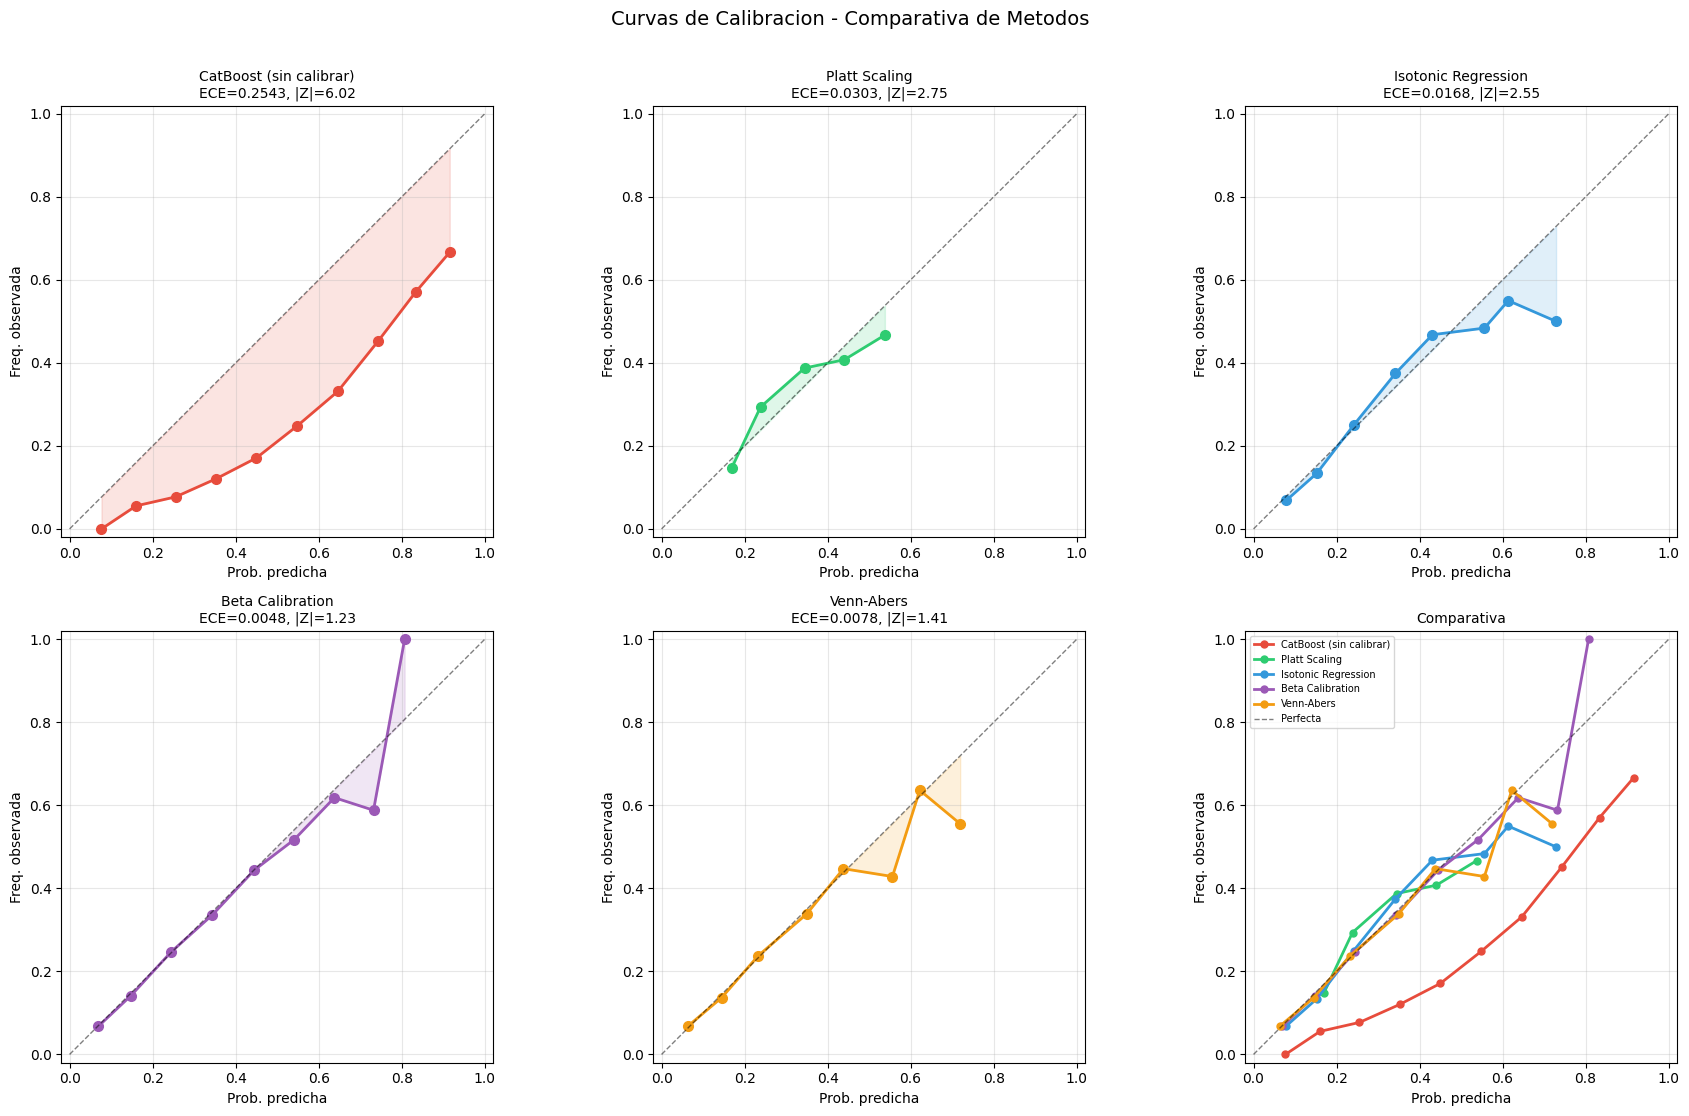

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

colors = {
    'CatBoost (sin calibrar)': '#e74c3c',
    'Platt Scaling': '#2ecc71',
    'Isotonic Regression': '#3498db',
    'Beta Calibration': '#9b59b6',
    'Venn-Abers': '#f39c12',
}

# Panel 1-5: curva individual de cada metodo
for i, (name, probs) in enumerate(methods.items()):
    ax = axes[i]
    prob_true, prob_pred = calibration_curve(y_test_flat, probs, n_bins=10, strategy='uniform')

    ax.plot(prob_pred, prob_true, 'o-', color=colors[name], lw=2, markersize=7)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color=colors[name])

    ece_i = expected_calibration_error(y_test_flat, probs)
    z_i, _, _ = spiegelhalter_z_test(y_test_flat, probs)

    ax.set_title(f'{name}\nECE={ece_i:.4f}, |Z|={abs(z_i):.2f}', fontsize=10)
    ax.set_xlabel('Prob. predicha')
    ax.set_ylabel('Freq. observada')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Panel 6: todas superpuestas
ax = axes[5]
for name, probs in methods.items():
    prob_true, prob_pred = calibration_curve(y_test_flat, probs, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', color=colors[name], lw=2, markersize=5, label=name)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfecta')
ax.set_title('Comparativa', fontsize=10)
ax.set_xlabel('Prob. predicha')
ax.set_ylabel('Freq. observada')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.suptitle('Curvas de Calibracion - Comparativa de Metodos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Descomposicion de Brier post-calibracion

Comparamos como cada metodo afecta a los componentes de la descomposicion de Brier.
Un buen calibrador debe reducir la **reliability** (mejora calibracion) sin reducir
la **resolution** (no degradar discriminacion).

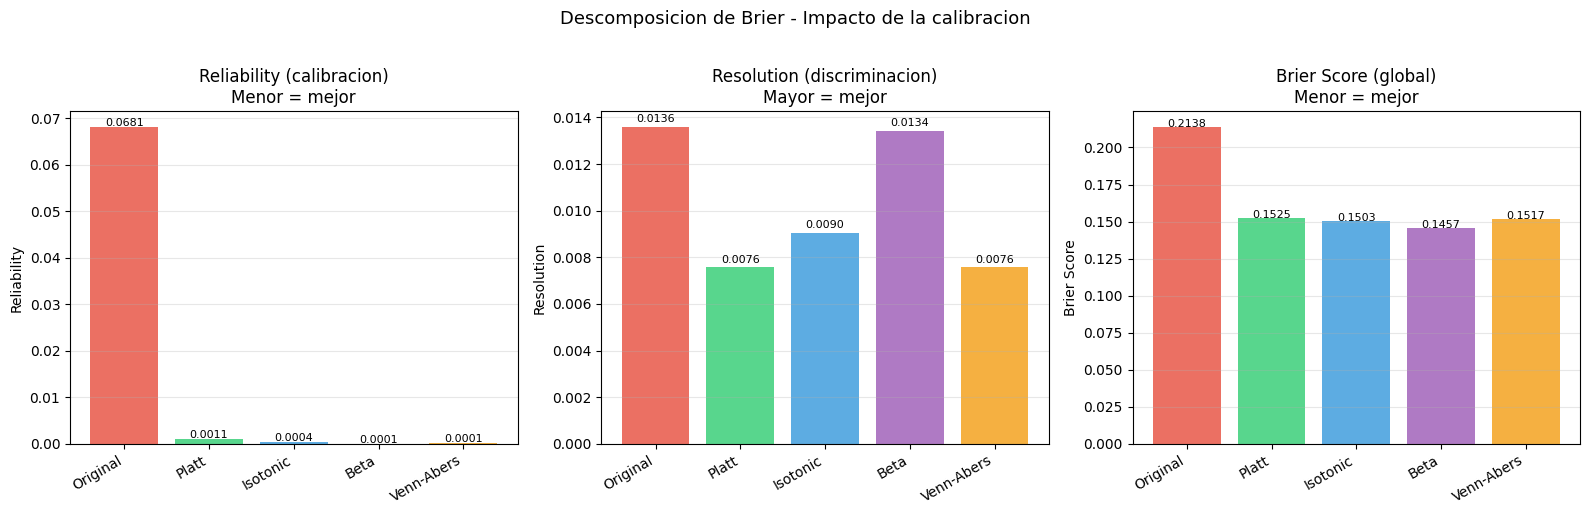

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

method_names = list(methods.keys())
reliabilities = []
resolutions = []
briers = []

for name, probs in methods.items():
    d = brier_decomposition(y_test_flat, probs)
    reliabilities.append(d['reliability'])
    resolutions.append(d['resolution'])
    briers.append(d['brier_direct'])

x_pos = np.arange(len(method_names))
short_names = ['Original', 'Platt', 'Isotonic', 'Beta', 'Venn-Abers']
bar_colors = [colors[n] for n in method_names]

# Reliability (menor = mejor)
axes[0].bar(x_pos, reliabilities, color=bar_colors, alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(short_names, rotation=30, ha='right')
axes[0].set_title('Reliability (calibracion)\nMenor = mejor')
axes[0].set_ylabel('Reliability')
for i, v in enumerate(reliabilities):
    axes[0].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Resolution (mayor = mejor)
axes[1].bar(x_pos, resolutions, color=bar_colors, alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(short_names, rotation=30, ha='right')
axes[1].set_title('Resolution (discriminacion)\nMayor = mejor')
axes[1].set_ylabel('Resolution')
for i, v in enumerate(resolutions):
    axes[1].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

# Brier Score (menor = mejor)
axes[2].bar(x_pos, briers, color=bar_colors, alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(short_names, rotation=30, ha='right')
axes[2].set_title('Brier Score (global)\nMenor = mejor')
axes[2].set_ylabel('Brier Score')
for i, v in enumerate(briers):
    axes[2].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Descomposicion de Brier - Impacto de la calibracion', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Verificacion: Se preserva la discriminacion (AUC)?

Un calibrador **nunca debe degradar el AUC-ROC**. Calibrar solo transforma las
probabilidades con una funcion monotona — esto preserva el ranking entre
muestras y, por tanto, el AUC.

Si un metodo cambia el AUC significativamente, es una senal de alerta.

### 6.4 Distribucion de probabilidades calibradas

Comparamos como cada metodo transforma la distribucion de probabilidades predichas.
Un buen calibrador deberia producir una distribucion cuya media se acerca a la
tasa base de default.

### 6.5 Test de Spiegelhalter antes y despues de calibrar

Verificamos formalmente si cada metodo de calibracion consigue que el modelo
pase el test de Spiegelhalter ($|Z| < 1.96$).

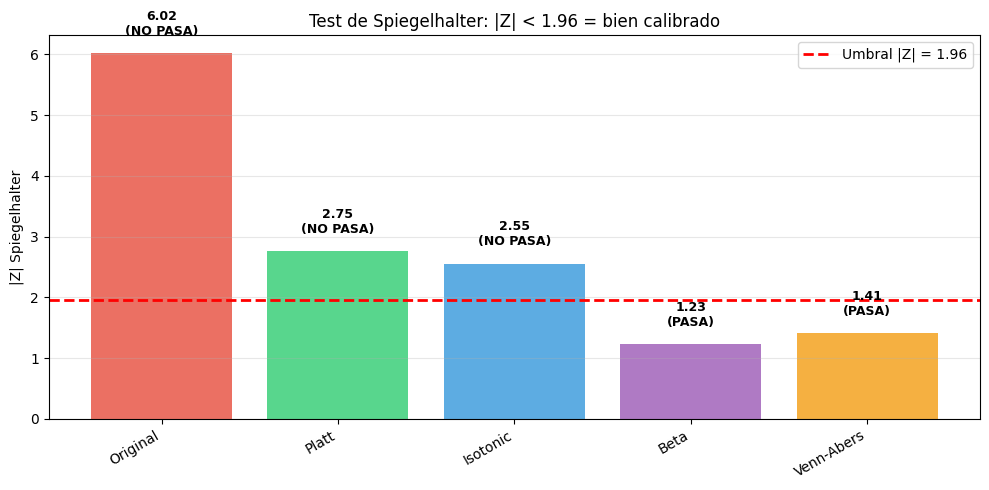

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

z_values = []
for name, probs in methods.items():
    z, _, _ = spiegelhalter_z_test(y_test_flat, probs)
    z_values.append(abs(z))

short_names = ['Original', 'Platt', 'Isotonic', 'Beta', 'Venn-Abers']
bar_colors_z = [colors[n] for n in methods.keys()]

bars = ax.bar(range(len(z_values)), z_values, color=bar_colors_z, alpha=0.8)
ax.axhline(y=1.96, color='red', linestyle='--', lw=2, label='Umbral |Z| = 1.96')
ax.set_xticks(range(len(z_values)))
ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.set_ylabel('|Z| Spiegelhalter')
ax.set_title('Test de Spiegelhalter: |Z| < 1.96 = bien calibrado')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (v, bar) in enumerate(zip(z_values, bars)):
    status = 'PASA' if v < 1.96 else 'NO PASA'
    ax.text(i, v + 0.3, f'{v:.2f}\n({status})', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

CVAP detectado: consolidando 1 folds por promedio


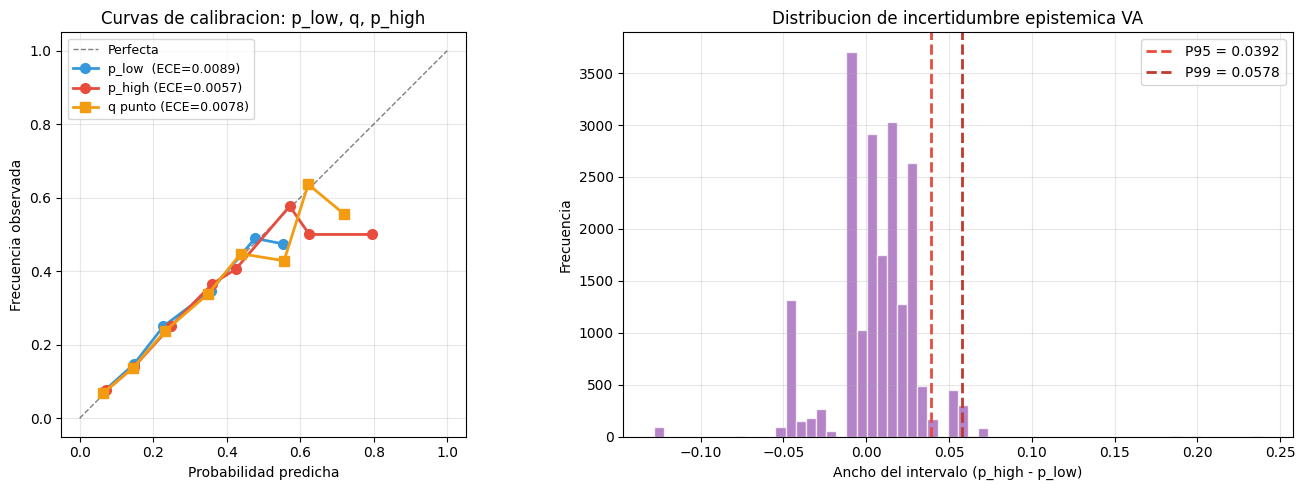

Estadisticas del ancho [p_high - p_low]:
  Min:     -0.1282
  Mediana: 0.0111
  Media:   0.0054
  P95:     0.0392
  P99:     0.0578
  Max:     0.2390

TOP 15 casos con MAYOR incertidumbre VA (candidatos a agente humano)
    score_crudo  p_low  q_punto  p_high  width  y_real
0        0.8803 0.5610   0.7006  0.8000 0.2390    True
1        0.5988 0.5610   0.7203  0.8000 0.2390   False
2        0.8302 0.5610   0.7203  0.8000 0.2390    True
3        0.8352 0.5610   0.7006  0.8000 0.2390    True
4        0.8644 0.5610   0.7203  0.8000 0.2390   False
5        0.7799 0.5610   0.7203  0.8000 0.2390   False
6        0.8439 0.6000   0.7308  0.8000 0.2000   False
7        0.8341 0.6000   0.7308  0.8000 0.2000    True
8        0.8186 0.6000   0.7308  0.8000 0.2000    True
9        0.8288 0.5610   0.6848  0.7500 0.1890   False
10       0.5426 0.2257   0.2785  0.2935 0.0678   False
11       0.4827 0.2257   0.2714  0.2935 0.0678   False
12       0.6147 0.2257   0.2714  0.2935 0.0678   False
13       0

In [ ]:
# ---------------------------------------------------------------
# Venn-Abers: intervalos [p_low, p_high] y derivacion a agente humano
# ---------------------------------------------------------------
# VA no solo produce una probabilidad puntual q, tambien produce un
# intervalo [p_low, p_high]:
#   p_low  = P(y=1 | asumo y_test=0)
#   p_high = P(y=1 | asumo y_test=1)
# Siempre p_low <= p_high.
#
# El ancho (p_high - p_low) mide INCERTIDUMBRE EPISTEMICA:
#   - ancho pequeno -> VA esta seguro de la probabilidad
#   - ancho grande  -> VA no tiene datos suficientes en esa zona
#                      del score -> candidato a revision humana

# Extraer p0, p1 del VA ya fiteado (CVAP 10-fold)
# OJO: con CVAP (inductive=False) la libreria devuelve p0p1 como una LISTA
# de n_splits arrays (n_test, 2), uno por fold. Hay que consolidar.
# Con IVAP (inductive=True) devuelve directamente un array (n_test, 2).
_, p0p1 = va_cal.predict_proba(X_test_filtered, p0_p1_output=True)
p0p1 = np.asarray(p0p1)
if p0p1.ndim == 3:
    # CVAP: (n_splits, n_test, 2) -> promediar sobre folds
    print(f"CVAP detectado: consolidando {p0p1.shape[0]} folds por promedio")
    p_low  = p0p1[:, :, 0].mean(axis=0)
    p_high = p0p1[:, :, 1].mean(axis=0)
else:
    # IVAP: (n_test, 2)
    p_low  = p0p1[:, 0]
    p_high = p0p1[:, 1]
width = p_high - p_low

# --- 1) Calibracion de p_low y p_high por separado
pt_lo, pp_lo = calibration_curve(y_test_flat, p_low,  n_bins=10, strategy='uniform')
pt_hi, pp_hi = calibration_curve(y_test_flat, p_high, n_bins=10, strategy='uniform')
pt_q,  pp_q  = calibration_curve(y_test_flat, probs_va, n_bins=10, strategy='uniform')

ece_lo = expected_calibration_error(y_test_flat, p_low)
ece_hi = expected_calibration_error(y_test_flat, p_high)
ece_q  = expected_calibration_error(y_test_flat, probs_va)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfecta')
axes[0].plot(pp_lo, pt_lo, 'o-', color='#3498db', lw=2, markersize=7,
             label=f'p_low  (ECE={ece_lo:.4f})')
axes[0].plot(pp_hi, pt_hi, 'o-', color='#e74c3c', lw=2, markersize=7,
             label=f'p_high (ECE={ece_hi:.4f})')
axes[0].plot(pp_q,  pt_q,  's-', color='#f39c12', lw=2, markersize=7,
             label=f'q punto (ECE={ece_q:.4f})')
axes[0].set_xlabel('Probabilidad predicha')
axes[0].set_ylabel('Frecuencia observada')
axes[0].set_title('Curvas de calibracion: p_low, q, p_high')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# --- 2) Distribucion del ancho del intervalo
p95 = np.percentile(width, 95)
p99 = np.percentile(width, 99)
axes[1].hist(width, bins=60, color='#9b59b6', alpha=0.75, edgecolor='white')
axes[1].axvline(p95, color='#e74c3c', ls='--', lw=2, label=f'P95 = {p95:.4f}')
axes[1].axvline(p99, color='#c0392b', ls='--', lw=2, label=f'P99 = {p99:.4f}')
axes[1].set_xlabel('Ancho del intervalo (p_high - p_low)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de incertidumbre epistemica VA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Estadisticas del ancho [p_high - p_low]:")
print(f"  Min:     {width.min():.4f}")
print(f"  Mediana: {np.median(width):.4f}")
print(f"  Media:   {width.mean():.4f}")
print(f"  P95:     {p95:.4f}")
print(f"  P99:     {p99:.4f}")
print(f"  Max:     {width.max():.4f}")

# --- 3) Ejemplos con MAYOR incertidumbre (candidatos a derivar)
idx_top = np.argsort(width)[::-1][:15]
cases_high = pd.DataFrame({
    'score_crudo': probs_test[idx_top],
    'p_low':       p_low[idx_top],
    'q_punto':     probs_va[idx_top],
    'p_high':      p_high[idx_top],
    'width':       width[idx_top],
    'y_real':      y_test_flat[idx_top],
})
print("\n" + "=" * 75)
print("TOP 15 casos con MAYOR incertidumbre VA (candidatos a agente humano)")
print("=" * 75)
print(cases_high.to_string(float_format=lambda x: f'{x:.4f}'))

# --- 4) Ejemplos con MENOR incertidumbre (contraste)
idx_bot = np.argsort(width)[:10]
cases_low = pd.DataFrame({
    'score_crudo': probs_test[idx_bot],
    'p_low':       p_low[idx_bot],
    'q_punto':     probs_va[idx_bot],
    'p_high':      p_high[idx_bot],
    'width':       width[idx_bot],
    'y_real':      y_test_flat[idx_bot],
})
print("\n" + "=" * 75)
print("TOP 10 casos con MENOR incertidumbre VA (decision automatizable)")
print("=" * 75)
print(cases_low.to_string(float_format=lambda x: f'{x:.4f}'))

# --- 5) Politica de derivacion: valida si el ancho segmenta riesgo
print("\n" + "=" * 75)
print("POLITICA DE DERIVACION BASADA EN ANCHO DEL INTERVALO VA")
print("=" * 75)

base_rate = y_test_flat.mean()
for pct_label, thr in [('P90', np.percentile(width, 90)),
                       ('P95', p95),
                       ('P99', p99)]:
    mask_route = width > thr
    n_route = mask_route.sum()
    if n_route == 0:
        continue
    dr_routed = y_test_flat[mask_route].mean()
    dr_auto   = y_test_flat[~mask_route].mean()
    print(f"\n  Umbral {pct_label} (width > {thr:.4f}):")
    print(f"    Casos derivados:         {n_route:>5} ({n_route/len(width)*100:.1f}%)")
    print(f"    Tasa default derivados:  {dr_routed:.4f}  (base: {base_rate:.4f})")
    print(f"    Tasa default automatico: {dr_auto:.4f}")
    print(f"    Ratio riesgo derivados/auto: {dr_routed/dr_auto:.2f}x")

print("\n  Interpretacion: si los casos derivados concentran MAS defaults que la")
print("  media, el ancho VA esta detectando incertidumbre epistemica genuina")
print("  (no solo ruido) -> la derivacion a agente aporta valor de negocio.")


### 6.6 Resumen visual: mejora porcentual sobre el modelo original

## Conclusiones

### Diagnostico: CatBoost necesitaba calibracion?

El analisis previo a la calibracion revelo que CatBoost con `auto_class_weights='Balanced'`
tiene **buena discriminacion** (AUC razonable) pero **mala calibracion**. Esto se confirmo
por tres vias independientes:
1. **Visual**: la curva de calibracion se aleja significativamente de la diagonal
2. **Brier decomposition**: la reliability (error de calibracion) es alta
3. **Test de Spiegelhalter**: |Z| >> 1.96, rechazamos la hipotesis de calibracion

Esto encaja con el diagnostico *"Alta discriminacion + mala calibracion -> calibrar post-hoc"*
del playbook de Manokhin (2025).

### Por que CatBoost estaba mal calibrado?

El parametro `auto_class_weights='Balanced'` asigna pesos inversamente proporcionales
a la frecuencia de cada clase (~4x para Default). Esto es necesario para que el modelo
detecte la clase minoritaria (sin el, Recall(Default) seria cercano a 0). Pero al
inflar el peso de Default durante el entrenamiento, las probabilidades predichas se
**distorsionan** — el modelo sobreestima la probabilidad de Default.

### Resultados de la calibracion y cual elegir

Los cuatro metodos mejoran la calibracion del modelo. Pero **"mejor" depende de que
se valore**:

| Criterio | Mejor metodo | Por que |
|---|---|---|
| **Mejor Brier/ECE en ESTE dataset** | Depende de los resultados (Platt, Isotonic o Beta pueden ganar) | La miscalibracion por `balanced weights` es sistematica y suave — los metodos parametricos la capturan bien |
| **Mas seguro (casi nunca empeora)** | **Venn-Abers** | Es el unico con garantias teoricas de calibracion. Manokhin (arXiv:2601.19944) lo confirma sobre 30 datasets |
| **Menos riesgo de sobreajuste** | Platt o Beta | 2-3 parametros vs no parametrico |
| **Sin suposiciones sobre la forma** | Isotonic o Venn-Abers | No asumen sigmoide ni Beta |

**La ventaja de Venn-Abers no es ganar en todas las metricas en un dataset concreto.**
Su ventaja es la **consistencia**: es el metodo que menos veces empeora las cosas.
Platt puede dar mejor Brier aqui y peor en otro dataset. Venn-Abers rara vez empeora.

En nuestro caso, la miscalibracion viene de `balanced weights`, que crea una distorsion
sistematica y suave. Esto es exactamente lo que una sigmoide (Platt) o una Beta capturan
bien con pocos parametros. Es como usar un canon (Venn-Abers con garantias formales) para
un problema que un bisturi (Platt) resuelve bien.

**Recomendacion practica:**
- **Si necesitas justificar ante un regulador** que las probabilidades estan calibradas
  con garantias formales -> **Venn-Abers**
- **Si quieres el mejor resultado puntual** en un dataset concreto y puedes validar
  -> **Isotonic** (con suficientes datos de calibracion) o **Beta**
- **Si quieres simplicidad y robustez** -> **Platt** (2 parametros, dificil de sobreajustar)

### Implicaciones para banca

1. **Siempre verificar calibracion** antes de usar probabilidades de un modelo para
   calculos financieros (perdidas esperadas, provisiones, pricing)
2. **El test de Spiegelhalter** es un test rapido y formal para decidir si calibrar
3. **Calibrar no degrada la discriminacion** (AUC se preserva) — solo corrige las
   probabilidades absolutas
4. **Venn-Abers** es especialmente relevante en contextos regulados donde se necesitan
   **garantias formales** sobre la calidad de las probabilidades, no solo el mejor
   numero en una metrica

### Leccion clave

> *"Las probabilidades de un modelo no son probabilidades reales hasta que se demuestre
> lo contrario. El Brier score solo no es suficiente — usa la descomposicion para
> separar calibracion de discriminacion, y el Z-test de Spiegelhalter para decidir
> si actuar. Y al elegir calibrador, distingue entre mejor-en-este-dataset (cualquiera
> puede ganar) y mas-seguro-en-general (Venn-Abers)."*